<a href="https://colab.research.google.com/github/SaiPrasad-Raut-007/the-model-prime/blob/main/model-prime-notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# # **Baseline Training, generalization and Fine tuning of CNN models trained on MNIST, QMNIST, KMNIST**

> ML task for the Delta Induction by Sai Prasad Raut

Here in this notebook i will be training a CNN model using PyTorch and train it on the MNIST dataset, QMNIST dataset, and finally on the KMNIST dataset.

The MNIST is a standard dataset that is made up of the handwritten digits that is used for training of Machine Learning Models.

The QMNIST is an extension the the MNIST dataset.

And finally the KMNIST dataset is the collection of handwritten japanese characters.

In [ ]:
# I will be using PyTorch framework for this task
import torch
from torchvision import transforms, datasets

# For MyCNN Class
import torch.nn as nn
import torch.nn.functional as F

# For evalution of the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# For plotting the data
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Phase 1: Baseline Training and Generalization

In [ ]:
# Defining transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
# Download train_dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 46.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.22MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.08MB/s]


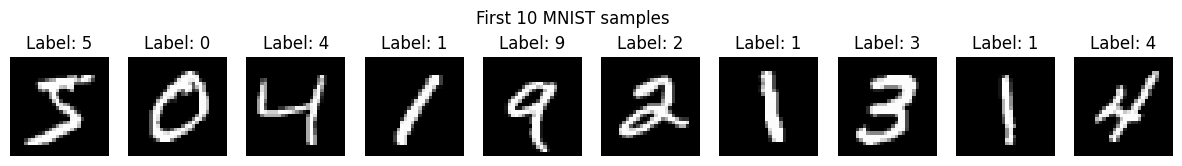

In [ ]:
# Show first 10 images
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(train_dataset[i][0].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {train_dataset[i][1]}")
    axes[i].axis('off')
plt.suptitle("First 10 MNIST samples")
plt.show()

In [ ]:
# Class for CNN architecture
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Layer 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, bias=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # For reducing
        # Layer 2
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, bias=True)

        self.dropout = nn.Dropout(p=0.5)
        # Output
        self.fc = nn.Linear(in_features=16*5*5, out_features=10, bias=True)

    def forward(self, x):
        # Passing through the two cnn layers
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Resize the tensors
        x = x.view(x.size(0), -1)

        #Applying dropout function
        x = self.dropout(x)

        x = self.fc(x) # Final Output
        return x # Returning the recieved output

In [ ]:
# Initializing the model
model = MyCNN()
# To run on the GPU accelarator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Data Loader function
data_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

# Defining cost function using Cross Entropy Loss Function
criterion = nn.CrossEntropyLoss()

# Defining optimizer... I am using the most commonly used optimizer here the Adaptive Moment Estimation
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Beginning the Training
epochs = 10
mnist_losses = []

for epoch in range(epochs):
    model.train()

    # Initilizing the running_loss variable for each epoch
    running_loss = 0

    for batch_index, (images, labels) in enumerate(data_loader):
        # To load on the GPU Accelarator
        images = images.to(device)
        labels = labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()

        # Pass images through the model to get outputs
        output = model(images)

        # Calculating the Loss
        loss = criterion(output, labels)

        # Backward Propagation
        loss.backward()
        optimizer.step()

        # Adding loss of each batch to running loss of the epoch
        running_loss += loss.item()

    # Calculating the average loss of the model
    average_loss = running_loss / len(data_loader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {average_loss:.4f}")
    mnist_losses.append(average_loss)

torch.save(model.state_dict(), 'mnist_model.pth')

Epoch 1/10 | Loss: 0.3693
Epoch 2/10 | Loss: 0.1531
Epoch 3/10 | Loss: 0.1255
Epoch 4/10 | Loss: 0.1128
Epoch 5/10 | Loss: 0.1050
Epoch 6/10 | Loss: 0.0962
Epoch 7/10 | Loss: 0.0929
Epoch 8/10 | Loss: 0.0855
Epoch 9/10 | Loss: 0.0859
Epoch 10/10 | Loss: 0.0798


In [ ]:
# Evaluating the model on the MNIST test set
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Defining the test data loader
test_data_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

# Stopping the model from tracking negative cost gradients since we don't require back propagation
model.eval()
with torch.no_grad():

    # Starting the evaluation loop
    # Initializing the prediction_list and the label_list
    prediction_list = []
    label_list = []

    for batch_index, (images, labels) in enumerate(test_data_loader):
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        _, predicted = torch.max(output, 1)

        # Adding the predicted and the labels to their associated lists
        prediction_list.append(predicted.cpu())
        label_list.append(labels.cpu())

# Flatten both the list to single tensors
all_predictions = torch.cat(prediction_list).numpy()
all_labels = torch.cat(label_list).numpy()

# Metrics of the model
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average='macro')
recall = recall_score(all_labels, all_predictions, average='macro')
f1 = f1_score(all_labels, all_predictions, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.9885
Precision: 0.9884
Recall:    0.9884
F1-Score:  0.9884


In [ ]:
# Evaluating the model on the QMNIST dataset
qmnist_dataset = datasets.QMNIST(root='./data', what='test', download=True, transform=transform)

# Defining the test data loader
qmnist_data_loader = torch.utils.data.DataLoader(
    dataset=qmnist_dataset,
    batch_size=64,
    shuffle=False
)

# Stopping the model from tracking negative cost gradients since we don't require back propagation
model.eval()
with torch.no_grad():

    # Starting the evaluation loop
    # Initializing the prediction_list and the label_list
    qmnist_prediction_list = []
    qmnist_label_list = []

    for batch_index, (images, labels) in enumerate(qmnist_data_loader):
        images = images.to(device)
        labels = labels.to(device)

        output = model(images)

        _, predicted = torch.max(output, 1)

        # Adding the predicted and the labels to their associated lists
        qmnist_prediction_list.append(predicted.cpu())
        qmnist_label_list.append(labels.cpu())

# Flatten both the list to single tensors
qmnist_all_predictions = torch.cat(qmnist_prediction_list).numpy()
qmnist_all_labels = torch.cat(qmnist_label_list).numpy()

# Metrics of the model
qmnist_accuracy = accuracy_score(qmnist_all_labels, qmnist_all_predictions)
qmnist_precision = precision_score(qmnist_all_labels, qmnist_all_predictions, average='macro')
qmnist_recall = recall_score(qmnist_all_labels, qmnist_all_predictions, average='macro')
qmnist_f1 = f1_score(qmnist_all_labels, qmnist_all_predictions, average='macro')

print(f"Accuracy:  {qmnist_accuracy:.4f}")
print(f"Precision: {qmnist_precision:.4f}")
print(f"Recall:    {qmnist_recall:.4f}")
print(f"F1-Score:  {qmnist_f1:.4f}")

100%|██████████| 9.74M/9.74M [00:00<00:00, 102MB/s]
100%|██████████| 527k/527k [00:00<00:00, 14.9MB/s]


Accuracy:  0.9865
Precision: 0.9863
Recall:    0.9864
F1-Score:  0.9863


## Comparision of the model performance across MNIST and QMNIST datasets

In [ ]:
data = {
    'Dataset': ['MNIST', 'QMNIST'],
    'Accuracy': [accuracy, qmnist_accuracy],
    'Precision': [precision, qmnist_precision],
    'Recall': [recall, qmnist_recall],
    'F1-Score': [f1, qmnist_f1]
}
df = pd.DataFrame(data)
df

,Dataset,Accuracy,Precision,Recall,F1-Score
0,MNIST,0.98850,0.988429,0.988414,0.988414
1,QMNIST,0.98645,0.986322,0.986355,0.986330


As we can observe here, the performance of the model dropped from MNIST to QMNSIT, slightly.
Since the QMNIST is harder and is more ambigous version of the MNIST dataset, the model finds it a bit more difficult to precisly tell which number it is. Hence, the slight drop in the performance.

# # Phase 2: Base Training vs Fine-tuning
Comparision between base trained model and fine-tuned model trained over the KMNIST dataset.

100%|██████████| 18.2M/18.2M [00:18<00:00, 988kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 3.04M/3.04M [00:02<00:00, 1.09MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 11.2MB/s]


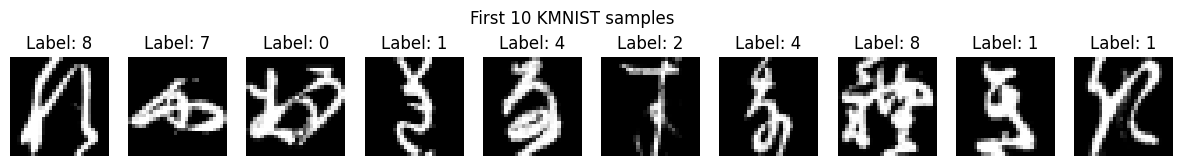

In [ ]:
kmnist_dataset = datasets.KMNIST(root='./data', train=True, download=True, transform=transform)

# Show first 10 images
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(kmnist_dataset[i][0].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {kmnist_dataset[i][1]}")
    axes[i].axis('off')
plt.suptitle("First 10 KMNIST samples")
plt.show()

In [ ]:
# Training the same model architecture on the KMNIST dataset
# Initializing KMNIST data loader
kmnist_data_loader = torch.utils.data.DataLoader(
    dataset=kmnist_dataset,
    batch_size=64,
    shuffle=True
)

# Initializing the model
kmnist_model = MyCNN().to(device)

# Initializing the optimizer
kmnist_optimizer = torch.optim.Adam(kmnist_model.parameters(), lr=0.001)

# Beginning the Training
epochs = 10
kmnist_losses = []

for epoch in range(epochs):
    kmnist_model.train()

    # Initilizing the running_loss variable for each epoch
    running_loss = 0

    for batch_index, (images, labels) in enumerate(kmnist_data_loader):
        # To load on the GPU Accelarator
        images = images.to(device)
        labels = labels.to(device)
        # Zero the gradients
        kmnist_optimizer.zero_grad()

        # Pass images through the model to get outputs
        output = kmnist_model(images)

        # Calculating the Loss
        loss = criterion(output, labels)

        # Backward Propagation
        loss.backward()
        kmnist_optimizer.step()

        # Adding loss of each batch to running loss of the epoch
        running_loss += loss.item()

    # Calculating the average loss of the model
    average_loss = running_loss / len(kmnist_data_loader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {average_loss:.4f}")
    kmnist_losses.append(average_loss)

Epoch 1/10 | Loss: 0.7532
Epoch 2/10 | Loss: 0.4303
Epoch 3/10 | Loss: 0.3742
Epoch 4/10 | Loss: 0.3520
Epoch 5/10 | Loss: 0.3326
Epoch 6/10 | Loss: 0.3171
Epoch 7/10 | Loss: 0.3108
Epoch 8/10 | Loss: 0.3115
Epoch 9/10 | Loss: 0.3000
Epoch 10/10 | Loss: 0.2950


In [ ]:
# Evaluating the model on the KMNIST dataset
kmnist_dataset = datasets.KMNIST(root='./data', train=False, download=True, transform=transform)

# Defining the test data loader
kmnist_data_loader = torch.utils.data.DataLoader(
    dataset=kmnist_dataset,
    batch_size=64,
    shuffle=False
)

# Stopping the model from tracking negative cost gradients
kmnist_model.eval()
with torch.no_grad():

    # Initializing the prediction_list and the label_list
    kmnist_prediction_list = []
    kmnist_label_list = []

    for batch_index, (images, labels) in enumerate(kmnist_data_loader):
        images = images.to(device)
        labels = labels.to(device)

        output = kmnist_model(images)

        _, predicted = torch.max(output, 1)

        # Adding the predicted and the labels to their associated lists
        kmnist_prediction_list.append(predicted.cpu())
        kmnist_label_list.append(labels.cpu())

# Flatten both the list to single tensors
kmnist_all_predictions = torch.cat(kmnist_prediction_list).numpy()
kmnist_all_labels = torch.cat(kmnist_label_list).numpy()

# Metrics of the model
kmnist_accuracy = accuracy_score(kmnist_all_labels, kmnist_all_predictions)
kmnist_precision = precision_score(kmnist_all_labels, kmnist_all_predictions, average='macro')
kmnist_recall = recall_score(kmnist_all_labels, kmnist_all_predictions, average='macro')
kmnist_f1 = f1_score(kmnist_all_labels, kmnist_all_predictions, average='macro')

print(f"Accuracy:  {kmnist_accuracy:.4f}")
print(f"Precision: {kmnist_precision:.4f}")
print(f"Recall:    {kmnist_recall:.4f}")
print(f"F1-Score:  {kmnist_f1:.4f}")

Accuracy:  0.8801
Precision: 0.8811
Recall:    0.8801
F1-Score:  0.8800


In [ ]:
# Finetunning the first model for the KMNIST dataset
finetuned_model = MyCNN().to(device)
finetuned_model.load_state_dict(torch.load('mnist_model.pth'))

# Initializing the optimizer
finetuned_kmnist_optimizer = torch.optim.Adam(finetuned_model.parameters(), lr=0.0001)

# Beginning the Training
epochs = 30
finetuned_kmnist_losses = []

for epoch in range(epochs):
    finetuned_model.train()

    # Initilizing the running_loss variable for each epoch
    running_loss = 0

    for batch_index, (images, labels) in enumerate(kmnist_data_loader):
        # To load on the GPU Accelarator
        images = images.to(device)
        labels = labels.to(device)
        # Zero the gradients
        finetuned_kmnist_optimizer.zero_grad()

        # Pass images through the model to get outputs
        output = finetuned_model(images)

        # Calculating the Loss
        loss = criterion(output, labels)

        # Backward Propagation
        loss.backward()
        finetuned_kmnist_optimizer.step()

        # Adding loss of each batch to running loss of the epoch
        running_loss += loss.item()

    # Calculating the average loss of the model
    average_loss = running_loss / len(kmnist_data_loader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {average_loss:.4f}")
    finetuned_kmnist_losses.append(average_loss)

Epoch 1/30 | Loss: 6.5453
Epoch 2/30 | Loss: 3.4753
Epoch 3/30 | Loss: 2.6264
Epoch 4/30 | Loss: 2.4244
Epoch 5/30 | Loss: 2.3495
Epoch 6/30 | Loss: 2.3181
Epoch 7/30 | Loss: 2.3060
Epoch 8/30 | Loss: 2.2913
Epoch 9/30 | Loss: 2.2767
Epoch 10/30 | Loss: 2.2585
Epoch 11/30 | Loss: 2.2423
Epoch 12/30 | Loss: 2.2072
Epoch 13/30 | Loss: 2.1682
Epoch 14/30 | Loss: 2.1144
Epoch 15/30 | Loss: 2.0649
Epoch 16/30 | Loss: 1.9922
Epoch 17/30 | Loss: 1.9156
Epoch 18/30 | Loss: 1.8527
Epoch 19/30 | Loss: 1.7801
Epoch 20/30 | Loss: 1.7262
Epoch 21/30 | Loss: 1.6554
Epoch 22/30 | Loss: 1.6088
Epoch 23/30 | Loss: 1.5501
Epoch 24/30 | Loss: 1.4883
Epoch 25/30 | Loss: 1.4477
Epoch 26/30 | Loss: 1.4010
Epoch 27/30 | Loss: 1.3559
Epoch 28/30 | Loss: 1.3231
Epoch 29/30 | Loss: 1.2864
Epoch 30/30 | Loss: 1.2601


In [ ]:
# Evaluating the finetuned_model on the KMNIST dataset
finetuned_kmnist_dataset = datasets.KMNIST(root='./data', train=False, download=True, transform=transform)

# Defining the test data loader
finetuned_kmnist_data_loader = torch.utils.data.DataLoader(
    dataset=finetuned_kmnist_dataset,
    batch_size=64,
    shuffle=False
)

# Stopping the model from tracking gradients for evaluation
finetuned_model.eval()
with torch.no_grad():

    # Initializing the prediction and label lists
    finetuned_kmnist_prediction_list = []
    finetuned_kmnist_label_list = []

    for batch_index, (images, labels) in enumerate(finetuned_kmnist_data_loader):
        images = images.to(device)
        labels = labels.to(device)

        output = finetuned_model(images)

        _, predicted = torch.max(output, 1)

        # Storing predictions and labels
        finetuned_kmnist_prediction_list.append(predicted.cpu())
        finetuned_kmnist_label_list.append(labels.cpu())

# Flattening into single tensors
finetuned_kmnist_all_predictions = torch.cat(finetuned_kmnist_prediction_list).numpy()
finetuned_kmnist_all_labels = torch.cat(finetuned_kmnist_label_list).numpy()

# Calculating metrics
finetuned_kmnist_accuracy = accuracy_score(finetuned_kmnist_all_labels, finetuned_kmnist_all_predictions)
finetuned_kmnist_precision = precision_score(finetuned_kmnist_all_labels, finetuned_kmnist_all_predictions, average='macro')
finetuned_kmnist_recall = recall_score(finetuned_kmnist_all_labels, finetuned_kmnist_all_predictions, average='macro')
finetuned_kmnist_f1 = f1_score(finetuned_kmnist_all_labels, finetuned_kmnist_all_predictions, average='macro')

print(f"Accuracy:  {finetuned_kmnist_accuracy:.4f}")
print(f"Precision: {finetuned_kmnist_precision:.4f}")
print(f"Recall:    {finetuned_kmnist_recall:.4f}")
print(f"F1-Score:  {finetuned_kmnist_f1:.4f}")

Accuracy:  0.7346
Precision: 0.7347
Recall:    0.7346
F1-Score:  0.7324


## Comparision of the performance between the Baseline model and the Fine-tuned model over the KMNIST dataset

In [ ]:
data = {
    'Model': ['Baseline', 'Fine-tuned'],
    'Accuracy': [kmnist_accuracy, finetuned_kmnist_accuracy],
    'Precision': [kmnist_precision, finetuned_kmnist_precision],
    'Recall': [kmnist_recall, finetuned_kmnist_recall],
    'F1 Score': [kmnist_f1, finetuned_kmnist_f1]
}

df = pd.DataFrame(data)
df

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.8801,0.881127,0.8801,0.880011
1,Fine-tuned,0.7346,0.734725,0.7346,0.732356


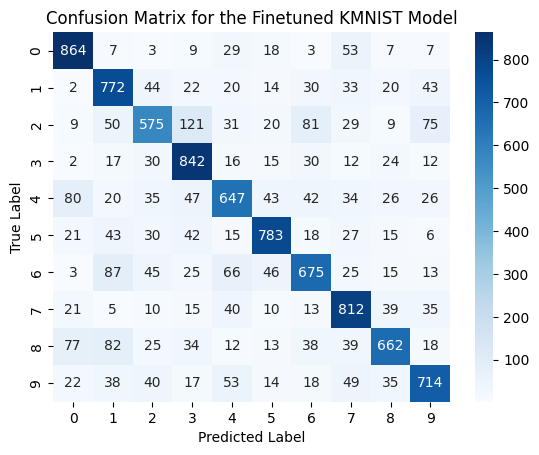

In [ ]:
# Confusion Matrix for the finetunned model
cm = confusion_matrix(finetuned_kmnist_all_labels, finetuned_kmnist_all_predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for the Finetuned KMNIST Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The baseline model performed way better in comparision to the fine-tuned model.

As the KMNIST dataset consists of japanese characters that are much more complex than the simple digits... these characters have mroe intricate strokes and many characters may look structurally similar to each other making them harder to distinguish.

Since the MNIST and KMNIST are different enough making the MNIST weights to not be trasfered properly. The model learned digit recognition patterns which are quite different from the japanese characters patterns, therefore starting from scratch worked better.

The confusion matrix shows that class 3, 7, and 0 had the highest correct predictions as seen by the brightest diagonal cells. The most confused pairs will be class 6 mistaken for 1, class 2 mistaken for 3 and class 9 mistaken for 2. This is likely because these japanese characters share similar stroke patterns and curves making them difficult to differ between even for the model.

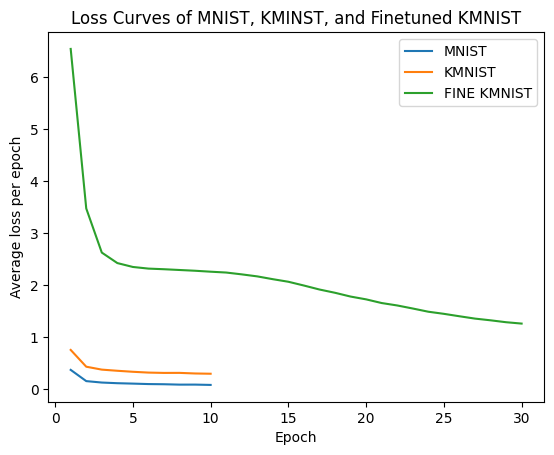

In [ ]:
# Plotting the loss curves of the MNIST model, KMNIST model and the Finetuned KMNIST model
plt.plot(range(1, len(mnist_losses)+1), mnist_losses, label='MNIST')
plt.plot(range(1, len(kmnist_losses)+1), kmnist_losses, label='KMNIST')
plt.plot(range(1, len(finetuned_kmnist_losses)+1), finetuned_kmnist_losses, label='FINE KMNIST')

plt.xlabel('Epoch')
plt.ylabel('Average loss per epoch')
plt.title('Loss Curves of MNIST, KMINST, and Finetuned KMNIST')

plt.legend()
plt.show()

MNIST training converged fastest and reached the lowest loss of 0.08 within 10 epochs.
KMNIST baseline also converged well reaching 0.28 within 10 epochs.
However the fine-tuned KMNIST model training started from a loss of nearly 7 and barely converged even after 30 epochs, confirming that transfer learning from MNIST did not help KMNIST and training from scratch was more effective for this dataset.